In [175]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
from os import listdir
from os.path import isfile, join
import json
import seaborn as sns

# **Plot 1**

In [27]:
# Experiments Information

d = 8
D = 130
T = 10000
N = 200
delta = 0.05
epsilon = 1e-06

# Smoothing factor
n = 10

In [28]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_return']

In [29]:
def running_mean(x, n):
    cumsum = np.cumsum(x, axis=1) 
    return (cumsum[:,n:] - cumsum[:,:-n]) / n

In [30]:
# algo_list = ['UCLK_C', 'UCRL2_VTR(BERNSTEIN)', 'UCRL2(HOEFFDING)']
algo_list = ['UCLK_C', 'UCRL2_VTR(BERNSTEIN)']
colors = sns.color_palette('bright', n_colors=len(algo_list))

In [31]:
R = 0
opt_reward = []
for i in range(T):
    R += 0.63
    opt_reward.append(R)

alg_name:  UCLK_C mean reward:  24394954.2 std:  5293871.548025826
alg_name:  UCRL2_VTR(BERNSTEIN) mean reward:  24856574.8 std:  2391536.2994880006


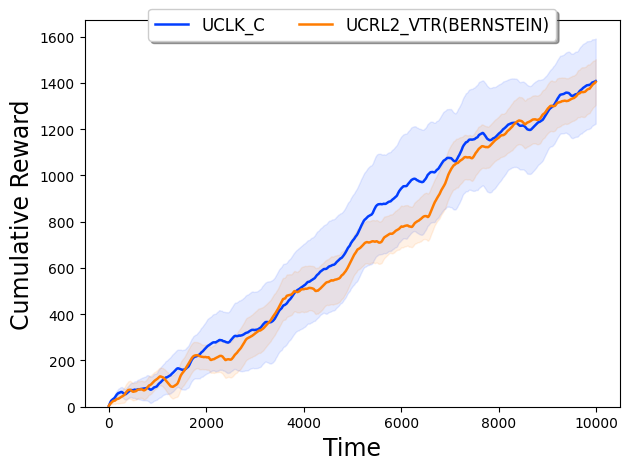

In [32]:
plt.figure()
for i in range(len(algo_list)):
    directory = f"./data/hardtolearn/{algo_list[i]}/regret_d_{d}_D_{D}.00_T_{T}_N_{N}_delta_{delta}_epsilon_{epsilon}/"
    file_list = [f for f in listdir(directory) if isfile(join(directory, f))]
    if '.DS_Store' in file_list:
        file_list.remove('.DS_Store')
    if '.ipynb_checkpoints' in file_list:
        file_list.remove('.ipynb_checkpoints')

    algo_returns = []
    for j in range(len(file_list)):
        r = json_parser(directory + file_list[j])
        algo_returns.append(r)

    data_mean = np.mean(running_mean(np.array(opt_reward) - algo_returns, n), axis=0)
    data_std = np.std(running_mean(np.array(opt_reward) - algo_returns, n), axis=0)  

    # data_mean = np.mean(np.array(opt_reward) - algo_returns, axis=0)
    # data_std = np.std(np.array(opt_reward) - algo_returns, axis=0)    
    
    timestep = np.arange(len(data_mean))

    plt.rc('font', size=10)        # 기본 폰트 크기
    plt.rc('axes', labelsize=17)   # x,y축 label 폰트 크기
    plt.rc('xtick', labelsize=10)  # x축 눈금 폰트 크기 
    plt.rc('ytick', labelsize=10)  # y축 눈금 폰트 크기
    plt.rc('legend', fontsize=12)  # 범례 폰트 크기
    # plt.rc('figure', titlesize=50) # figure title 폰트 크기

    plt.fill_between(timestep, data_mean + 0.3 * data_std, data_mean - 0.3 * data_std, alpha=0.1, edgecolor=colors[i], facecolor=colors[i])
    plt.plot(timestep, data_mean, color=colors[i], linewidth=1.8, label=algo_list[i])
    
    print("alg_name: ", algo_list[i], "mean reward: ", np.mean(np.sum(algo_returns, axis=1)),
          "std: ", np.std(np.sum(algo_returns, axis=1)))
    
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), fancybox=True, shadow=True, ncol=3)
plt.xlabel("Time")
plt.ylabel("Cumulative Reward")
plt.ylim(0)
plt.tight_layout()
plt.savefig(f'(Hard-to-learn, Rewards)_regret_d_{d}_D_{D}_T_{T}_N_{N}_delta_{delta}_epsilon_{epsilon}' + '.pdf', dpi=300)  # format.pdf
plt.show()

# **Plot 2**

In [207]:
# Experiments Information

d = 8
D = 140
T = 10000
N = 200
delta = 0.05
epsilon = 1e-06

# Smoothing factor
n = 1000

In [208]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_regret']

In [209]:
def running_mean(x, n):
    cumsum = np.cumsum(x, axis=1) 
    return (cumsum[:,n:] - cumsum[:,:-n]) / n

In [210]:
# algo_list = ['UCLK_C', 'UCRL2_VTR(BERNSTEIN)', 'UCRL2(HOEFFDING)']
algo_list = ['UCLK_C', 'UCRL2_VTR(BERNSTEIN)']
colors = sns.color_palette('bright', n_colors=len(algo_list))

alg_name:  UCLK_C mean reward:  6644048.7 std:  5733003.75242567
alg_name:  UCRL2_VTR(BERNSTEIN) mean reward:  8940039.0 std:  1852617.2216426684


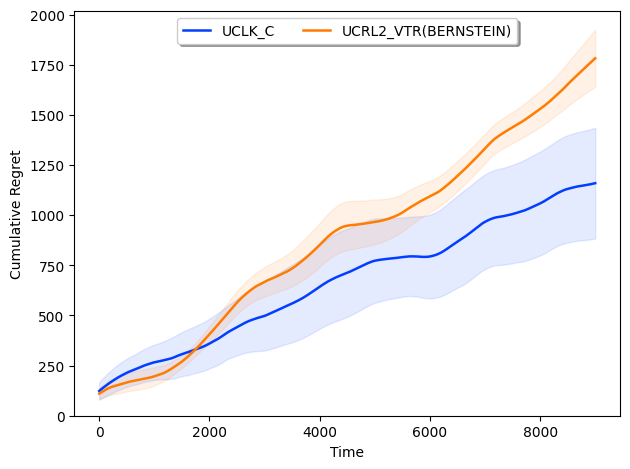

In [211]:
plt.figure()
for i in range(len(algo_list)):
    directory = f"./data/hardtolearn/{algo_list[i]}/regret_d_{d}_D_{D}.00_T_{T}_N_{N}_delta_{delta}_epsilon_{epsilon}/"
    file_list = [f for f in listdir(directory) if isfile(join(directory, f))]
    if '.DS_Store' in file_list:
        file_list.remove('.DS_Store')
    if '.ipynb_checkpoints' in file_list:
        file_list.remove('.ipynb_checkpoints')

    algo_regret = []
    for j in range(len(file_list)):
        r = json_parser(directory + file_list[j])
        algo_regret.append(r)

    data_mean = np.mean(running_mean(algo_regret, n), axis=0)
    data_std = np.std(running_mean(algo_regret, n), axis=0)  
    
    # data_mean = np.mean(algo_returns, axis=0)
    # data_std = np.std(algo_returns, axis=0)    
    
    timestep = np.arange(len(data_mean))

    plt.rc('font', size=10)        # 기본 폰트 크기
    plt.rc('axes', labelsize=10)   # x,y축 label 폰트 크기
    plt.rc('xtick', labelsize=10)  # x축 눈금 폰트 크기 
    plt.rc('ytick', labelsize=10)  # y축 눈금 폰트 크기
    plt.rc('legend', fontsize=10)  # 범례 폰트 크기
    # plt.rc('figure', titlesize=50) # figure title 폰트 크기

    plt.fill_between(timestep, data_mean + 0.3 * data_std, data_mean - 0.3 * data_std, alpha=0.1, edgecolor=colors[i], facecolor=colors[i])
    plt.plot(timestep, data_mean, color=colors[i], linewidth=1.8, label=algo_list[i])
    
    print("alg_name: ", algo_list[i], "mean reward: ", np.mean(np.sum(algo_regret, axis=1)),
          "std: ", np.std(np.sum(algo_regret, axis=1)))
    
handles, labels = plt.gca().get_legend_handles_labels()
# loc: 'best', 'upper right', 'upper left', 'lower left', 'lower right', 'right', 'center left', 'center right', 'lower center', 'upper center', 'center'
# plt.legend(handles, labels, loc='center', bbox_to_anchor=(0.5, 1.05), fancybox=True, shadow=True, ncol=3)
plt.legend(handles, labels, loc='upper center', fancybox=True, shadow=True, ncol=3)
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.ylim(0)
plt.tight_layout()
plt.savefig(f'(Hard-to-learn, Rewards)_regret_d_{d}_D_{D}_T_{T}_N_{N}_delta_{delta}_epsilon_{epsilon}' + '.pdf', dpi=300)  # format.pdf
plt.show()

# **Plot 3**

In [225]:
# Experiments Information

d = 8
D = 90
T = 10000
N = 50
delta = 0.05
epsilon = 1e-06

In [226]:
def json_parser(path):
    with open(path) as f:
        data = json.load(f)
        return data['cumulative_regret'][-1]

In [227]:
# algo_list = ['UCLK_C', 'UCRL2_VTR(BERNSTEIN)', 'UCRL2(HOEFFDING)']
# algo_list = ['UCLK_C', 'UCRL2_VTR(BERNSTEIN)']
algo_list = ['UCRL2_VTR(BERNSTEIN)']
algo_list = ['UCLK_C']
colors = sns.color_palette('bright', n_colors=len(algo_list))

-90
1198
-840
2043
508
1913
-3047
2092
4478
5184


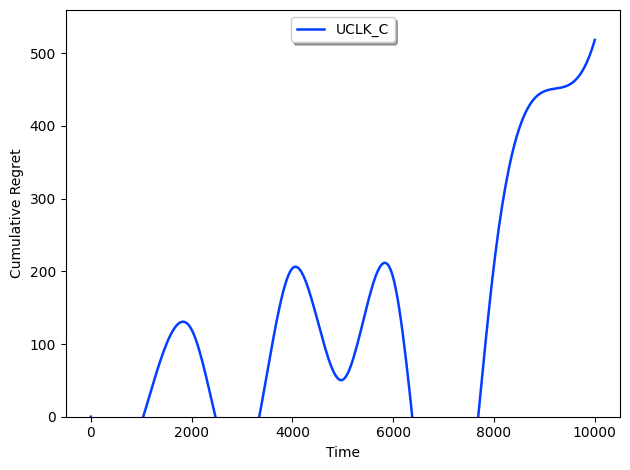

In [237]:
plt.figure()
for i in range(len(algo_list)):
    regret = [0]
    for t in range(1000, 11000, 1000):
        directory = f"./data/hardtolearn/{algo_list[i]}(discrete)/regret_d_{d}_D_{D}.00_T_{t}_N_{N}_delta_{delta}_epsilon_{epsilon}/"
        file_list = [f for f in listdir(directory) if isfile(join(directory, f))]
        if '.DS_Store' in file_list:
            file_list.remove('.DS_Store')
        if '.ipynb_checkpoints' in file_list:
            file_list.remove('.ipynb_checkpoints')

        reg = 0
        for j in range(len(file_list)):
            reg += json_parser(directory + file_list[j])

        print(reg)
        regret.append(reg / 10)

    timestep = np.arange(len(regret)) * 1000

    # Create a smooth spline fit
    spline = make_interp_spline(timestep, regret, k=3)  # k=3 for cubic spline
    smooth_timestep = np.linspace(timestep.min(), timestep.max(), 300)  # 300 points for smoothness
    smooth_regret = spline(smooth_timestep)

    plt.rc('font', size=10)        # Default font size
    plt.rc('axes', labelsize=10)   # x, y-axis label font size
    plt.rc('xtick', labelsize=10)  # x-axis tick font size
    plt.rc('ytick', labelsize=10)  # y-axis tick font size
    plt.rc('legend', fontsize=10)  # Legend font size

    # Plot the smoothed spline curve
    plt.plot(smooth_timestep, smooth_regret, color=colors[i], linewidth=1.8, label=algo_list[i])
    # plt.scatter(timestep, regret, color=colors[i], s=40, label=algo_list[i], edgecolors='k', zorder=5)  # Markers at original data points
    
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, labels, loc='upper center', fancybox=True, shadow=True, ncol=3)
plt.xlabel("Time")
plt.ylabel("Cumulative Regret")
plt.ylim(0)
plt.tight_layout()
# plt.savefig(f'(Hard-to-learn, Rewards)_test_regret_d_{d}_D_{D}_T_{T}_N_{N}_delta_{delta}_epsilon_{epsilon}.pdf', dpi=300)
plt.show()